# Задачи Римана для уравнений Эйлера
Лабораторная работа 1 · тема 11: **The Well: Euler Multi-quadrants**.

Цель — решить задачу движения идеального газа с кусочно-постоянными начальными
условиями, подобрать показатель адиабаты и сравнить результат с опубликованными данными.

Здесь три эксперимента: фрагмент The Well, два набора начальных условий ANU и
гладкая трёхмерная волна с известным точным решением. Поля используются в численных единицах источников; перевод к единицам СИ не выполняется.

In [1]:
from pathlib import Path
import sys, json
from dataclasses import asdict

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown
from euler_lab.solver import EulerSolver, conservative_to_primitive, primitive_to_conservative
from euler_lab.analysis import equation_graph, fit_gamma, error_metrics, coarsen_conservative, extrude_planar
from euler_lab.calibration import fit_trajectory_gamma
from euler_lab.data import load_well_sample, load_anu_case, verify_local_data
from euler_lab.experiments import quadrant_state, entropy_wave
from euler_lab.plotting import plot_equation_graph, plot_comparison, plot_volume

plt.rcParams.update({"font.size": 10, "figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.family": "DejaVu Sans"})
DATA = ROOT / "data" / "processed"
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Уравнения и постановка

Журнальная основа — Lax и Liu, *SIAM Journal on Scientific Computing* (1998),
[DOI: 10.1137/S1064827595291819](https://doi.org/10.1137/S1064827595291819).
Двумерные тесты также описаны у Liska и Wendroff (2003),
[DOI: 10.1137/S1064827502402120](https://doi.org/10.1137/S1064827502402120).

Для трёх пространственных координат система имеет вид

$$U_t+\partial_x F_x(U)+\partial_y F_y(U)+\partial_z F_z(U)=0,$$
$$U=(\rho,m_x,m_y,m_z,E)^T,\quad \mathbf v=\mathbf m/\rho,\qquad
p=(\gamma-1)\left(E-\frac{|\mathbf m|^2}{2\rho}\right).$$

Здесь $\rho$ — плотность, $\mathbf m$ — плотность импульса, $E$ — полная энергия
на единицу объёма. В частности,

$$F_x=(m_x,m_xu+p,m_yu,m_zu,(E+p)u)^T,$$
$$F_y=(m_y,m_xv,m_yv+p,m_zv,(E+p)v)^T,$$
$$F_z=(m_z,m_xw,m_yw,m_zw+p,(E+p)w)^T.$$

В The Well и таблицах ANU исходные данные **двумерные**. Для сопоставления с 3D-солвером
используется частный случай $\partial_zU=0$, $w=0$, одинаковый во всех слоях.
Это не независимый трёхмерный датасет. Отдельная проверка ниже содержит зависимость
от всех трёх координат и времени.

Вариации задачи: показатель адиабаты $\gamma$, начальные состояния квадрантов,
открытые или периодические границы. В численных сравнениях изменяется только
оговорённый параметр; внешние силы и вязкость отсутствуют.

| Величина | Выбор | Зачем |
|---|---|---|
| Вектор физических параметров $\theta=(\gamma)$ | ожидается 1.4; поиск [1.05, 1.9] | Выбран файл для сухого воздуха |
| Начальное приближение $\gamma_0$ | 1.3 | Отличается от ожидаемого |
| CFL | 0.4 | Запас устойчивости явной схемы |
| Сетка The Well | $64\times64\times4$, область $[0,1]^3$ | Умеренное время расчёта |
| Границы The Well | outflow по x/y, periodic по z | Открытая исходная задача |
| ANU | случаи 3 и 6; $32^2,64^2,128^2$ | Разные начальные разрывы |
| Полноценная 3D-проверка | $16^3$ и $32^3$, periodic | Сравнение с точным решением |

CFL и размеры сетки — численные настройки, а не подбираемые свойства газа.

## 2. Граф вычислений

Используется `networkx.DiGraph`. Общие узлы скорости, кинетической энергии и
давления переиспользуются в трёх потоках. Граф описывает вычисление правой части
в один момент времени; обратная связь по времени здесь не нарисована.

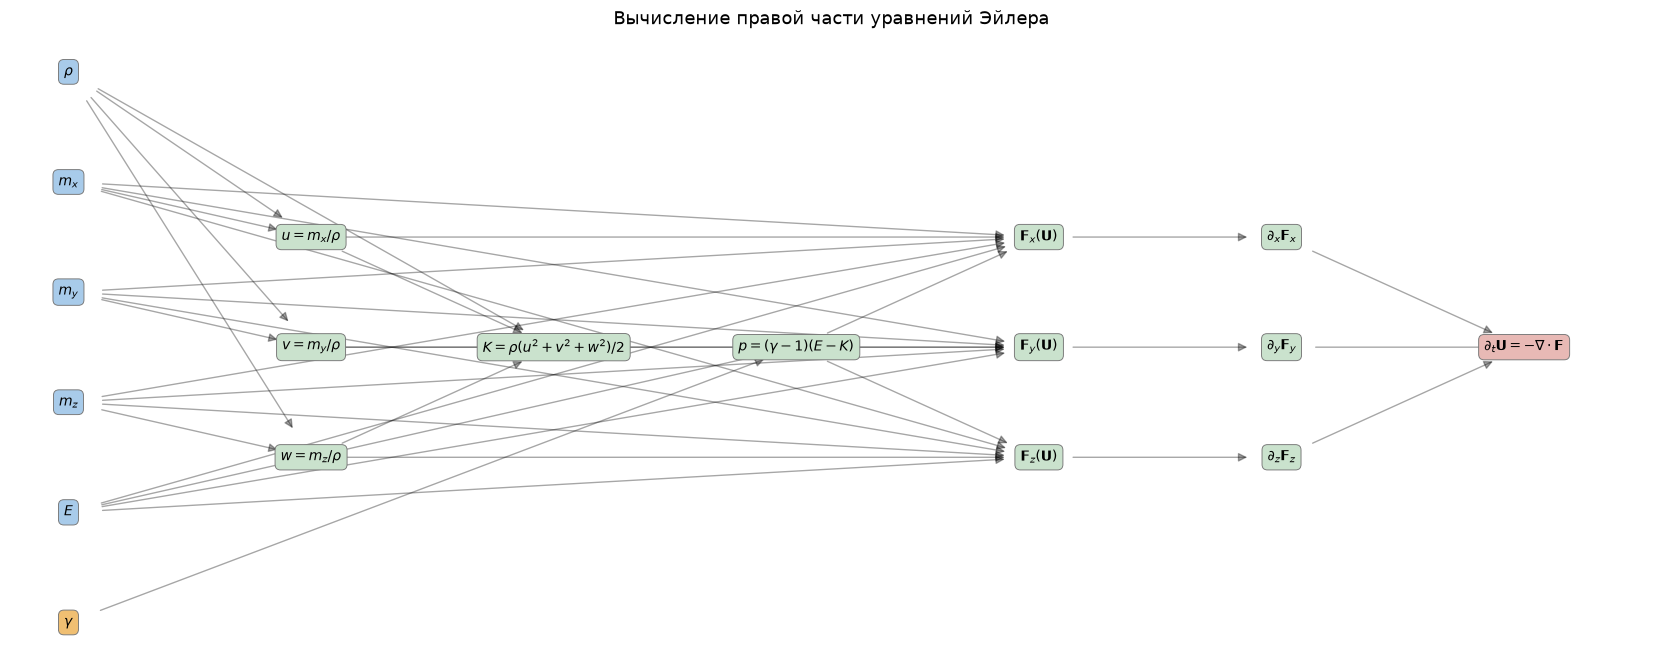

Узлов: 18, связей: 37


In [2]:
graph = equation_graph()
assert nx.is_directed_acyclic_graph(graph)
fig = plot_equation_graph(graph)
fig.savefig(FIGURES / "equation_graph.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"Узлов: {graph.number_of_nodes()}, связей: {graph.number_of_edges()}")

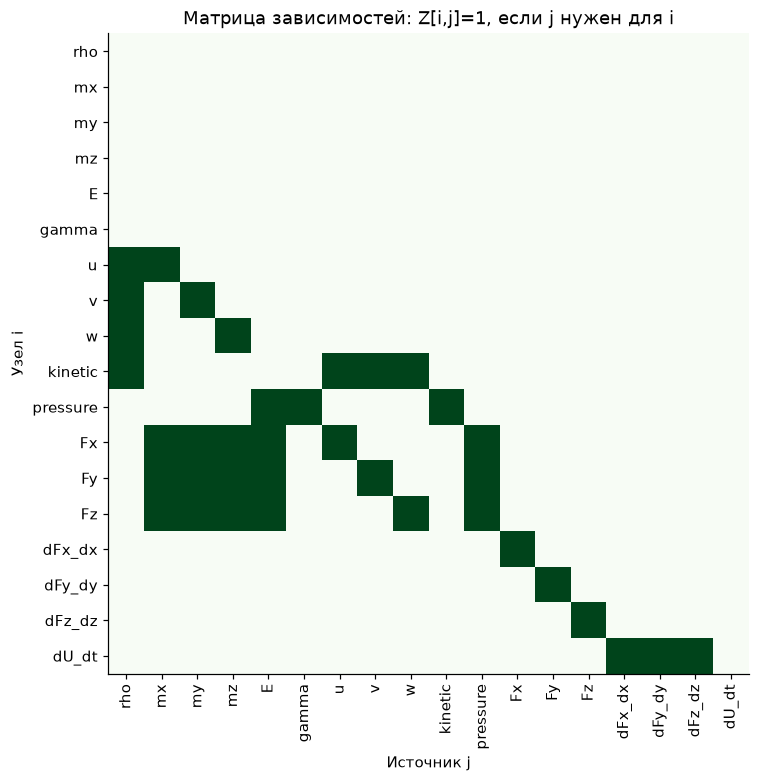

In [3]:
node_order = list(nx.topological_sort(graph))
# В столбце j стоит источник, в строке i — зависимый от него узел.
adjacency = nx.to_numpy_array(graph, nodelist=node_order).T
fig, ax = plt.subplots(figsize=(8, 7), layout="constrained")
ax.imshow(adjacency, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(node_order)), node_order, rotation=90)
ax.set_yticks(range(len(node_order)), node_order)
ax.set(title="Матрица зависимостей: Z[i,j]=1, если j нужен для i", xlabel="Источник j", ylabel="Узел i")
fig.savefig(FIGURES / "adjacency.png", dpi=150)
plt.show()

## 3. Данные из двух источников

1. **Polymathic AI / The Well**: независимый численный расчёт Clawpack с открытыми
границами, $\gamma=1.4$. Из test-файла взяты траектория 0 и кадры
`0, 1, 2, 4, 6, 8, 10`. Исходная сетка $512^2$ усреднена блоками $8\times8$
до $64^2$ **по консервативным переменным**.
2. **ANU / Fyris**: опубликованные числовые начальные условия задач Римана.
Это второй источник данных, но не второй готовый численный эталон.

Загрузка выполняется по HTTPS скриптом `scripts/download_data.py`. Для HDF5
используются запросы диапазонов байтов: получено около 58 MB вместо всего файла
5.3 GB. В репозитории сохранена небольшая обработанная выборка, поэтому повторный
расчёт не требует сети. URL, фиксированная версия источника, преобразования и
SHA-256 находятся в `data/processed/sources.json`.

**Соглашения о метаданных.** Временная ось HDF5 содержит номера `0…100`, а не секунды.
Здесь принято $t=0.015\,k$ по интервалу записи из карточки источника; в самом HDF5
нет атрибута dt. Метки x/y включают оба конца $[0,1]$. Для конечных объёмов принята
область $[0,1]$ и шаг $1/N$; исходные метки сохранены отдельно. Эти интерпретации
ограничивают точность количественного сопоставления. Ошибочный атрибут
`n_trajectories=-1550` не используется — фактическая форма массива содержит 10 траекторий.

In [4]:
manifest = verify_local_data(DATA)
sample = load_well_sample(DATA)
gamma_expected = float(sample["gamma"])
times = sample["time"]
reference = conservative_to_primitive(sample["conserved"], gamma_expected)
print("Форма консервативных полей:", sample["conserved"].shape)
print("Номера кадров:", sample["source_time"].astype(int))
print("Время модели по интервалу карточки:", times)
print("Контрольные суммы сохранённых файлов: OK")
print("Среднее |p(mean U) - mean p|:", float(np.mean(abs(reference[..., 4] - sample["pressure"]))))

Форма консервативных полей: (7, 64, 64, 5)
Номера кадров: [ 0  1  2  4  6  8 10]
Время модели по интервалу карточки: [0.    0.015 0.03  0.06  0.09  0.12  0.15 ]
Контрольные суммы сохранённых файлов: OK
Среднее |p(mean U) - mean p|: 0.0015096795641793143


После усреднения $p(\overline U)$ обычно отличается от $\overline p$: квадрат
импульса нелинеен. Для сравнения солверов ниже используется $p(\overline U)$,
то есть давление разрешённого состояния на грубой сетке. Подбор по уравнению
состояния выполнен на исходных ячейках **до** усреднения.

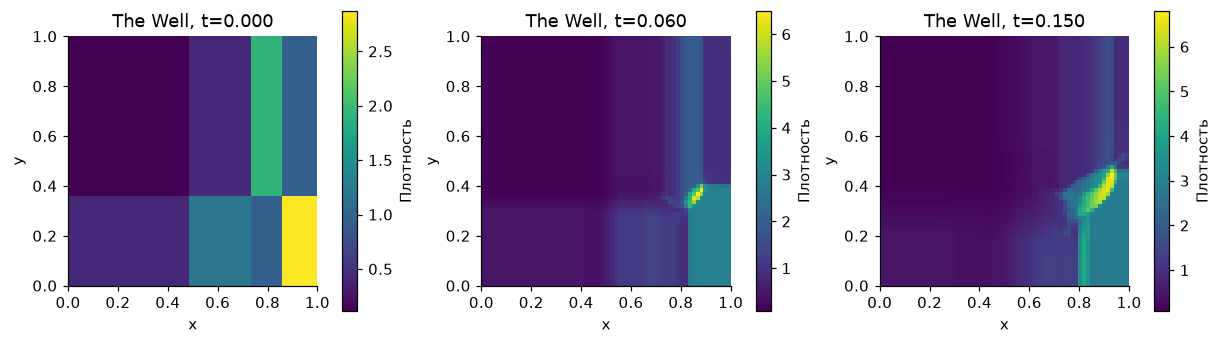

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), layout="constrained")
for ax, frame in zip(axes, (0, 3, 6)):
    shown = ax.imshow(reference[frame, ..., 0].T, origin="lower", extent=(0,1,0,1), cmap="viridis")
    ax.set(title=f"The Well, t={times[frame]:.3f}", xlabel="x", ylabel="y")
    fig.colorbar(shown, ax=ax, shrink=0.8, label="Плотность")
fig.savefig(FIGURES / "well_data.png", dpi=150)
plt.show()

## 4. Подбор показателя адиабаты по уравнению состояния

Минимизируется сумма квадратов остатков
$$r_i(\gamma)=(\gamma-1)\left(E_i-\frac{m_{xi}^2+m_{yi}^2}{2\rho_i}\right)-p_i.$$
Оптимизатор — `scipy.optimize.least_squares` с границами для $\gamma$.
Обучение: 1000 исходных ячеек кадра 2 ($t=0.03$). Проверка: 1000 ячеек
кадра 10 ($t=0.15$). Выборка зафиксирована seed=11.

Поля созданы симулятором идеального газа, поэтому здесь проверяется восстановление
его термодинамического параметра. Малый остаток этого подбора ещё не означает,
что наш солвер хорошо воспроизводит динамику.

Ожидалось gamma = 1.400000; получено 1.399999978
RMSE обучения: 1.933e-08; RMSE проверки: 2.248e-08


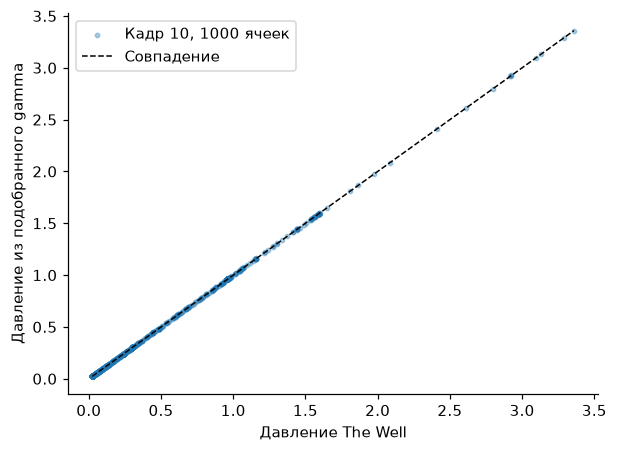

In [6]:
train, test = sample["eos_train"], sample["eos_test"]
eos_fit = fit_gamma(train[:,0], train[:,1:3], train[:,3], train[:,4])
assert eos_fit.success
internal_test = test[:,3] - np.sum(test[:,1:3]**2, axis=1) / (2 * test[:,0])
pressure_test = (eos_fit.gamma - 1) * internal_test
eos_test_metrics = error_metrics(pressure_test, test[:,4])
print(f"Ожидалось gamma = {gamma_expected:.6f}; получено {eos_fit.gamma:.9f}")
print(f"RMSE обучения: {eos_fit.rmse:.3e}; RMSE проверки: {eos_test_metrics['rmse']:.3e}")
fig, ax = plt.subplots(figsize=(5.5, 4), layout="constrained")
ax.scatter(test[:,4], pressure_test, s=8, alpha=0.35, label="Кадр 10, 1000 ячеек")
limits = [float(test[:,4].min()), float(test[:,4].max())]
ax.plot(limits, limits, "k--", linewidth=1, label="Совпадение")
ax.set(xlabel="Давление The Well", ylabel="Давление из подобранного gamma")
ax.legend()
fig.savefig(FIGURES / "gamma_fit.png", dpi=150)
plt.show()

## 5. Численный солвер и подбор по движению газа

Используется явная нерасщеплённая схема конечных объёмов первого порядка с потоком Русанова:
$$\widehat F(U_L,U_R)=\frac{F(U_L)+F(U_R)}2
-\frac{\alpha}{2}(U_R-U_L),\quad
\alpha=\max(|v_{n,L}|+c_L,|v_{n,R}|+c_R),\quad c=\sqrt{\gamma p/\rho}.$$
Обновление — сумма разностей потоков по x, y и z. Шаг времени выбирается по
$$\Delta t=\frac{\mathrm{CFL}}{a_x/\Delta x+a_y/\Delta y+a_z/\Delta z},
\qquad a_d=\max_{\rm cells}(|v_d|+c).$$
При достижении очередного времени вывода шаг сокращается. В outflow-ячейках
за границей повторяется крайнее состояние. Отрицательные плотности/давления
вызывают ошибку, а не незаметную обрезку.

Дополнительно подберём $\gamma$ по двум ранним кадрам движения, сохраняя одно и то же
наблюдаемое начальное примитивное состояние. Минимизируем среднюю нормированную
квадратичную ошибку плотности и давления при $t=0.015$ и $t=0.03$ методом
`minimize_scalar(method="bounded")`. Масштабы — RMS каждого поля на обучающих кадрах;
начальный кадр в функцию потерь не входит. Поздние кадры $t\ge0.06$ используются
только для проверки. Такой параметр может компенсировать ошибки грубой схемы,
поэтому его нельзя автоматически считать истинным свойством газа.

In [7]:
n, nz = 64, 4
spacing = (1/n, 1/n, 1/nz)
initial = extrude_planar(reference[0], nz)
reference_3d = extrude_planar(reference, nz)
trajectory_fit = fit_trajectory_gamma(initial, times[:3], reference_3d[:3], spacing)
assert trajectory_fit.success
print(f"gamma по ранней динамике: {trajectory_fit.gamma:.6f}; loss={trajectory_fit.loss:.6g}")
print(f"Вызовов солвера при подборе: {trajectory_fit.evaluations}")

predictions = {}
for label, gamma in (("До подбора", 1.3), ("По уравнению состояния", eos_fit.gamma),
                     ("По ранней динамике", trajectory_fit.gamma)):
    predictions[label] = EulerSolver(gamma=gamma).solve(initial, times, spacing)
    print(label, "— расчёт готов")
solution = predictions["По уравнению состояния"]

gamma по ранней динамике: 1.118484; loss=0.00918262
Вызовов солвера при подборе: 7


До подбора — расчёт готов


По уравнению состояния — расчёт готов


По ранней динамике — расчёт готов


**Проверка на поздних кадрах t = 0.06, 0.09, 0.12, 0.15:**

| Параметр | RMSE rho | rel.L2 rho | RMSE p | rel.L2 p |
|---|---:|---:|---:|---:|
| До подбора | 0.24762 | 21.47% | 0.13113 | 20.75% |
| По уравнению состояния | 0.25938 | 22.49% | 0.13846 | 21.92% |
| По ранней динамике | 0.22626 | 19.62% | 0.12899 | 20.42% |

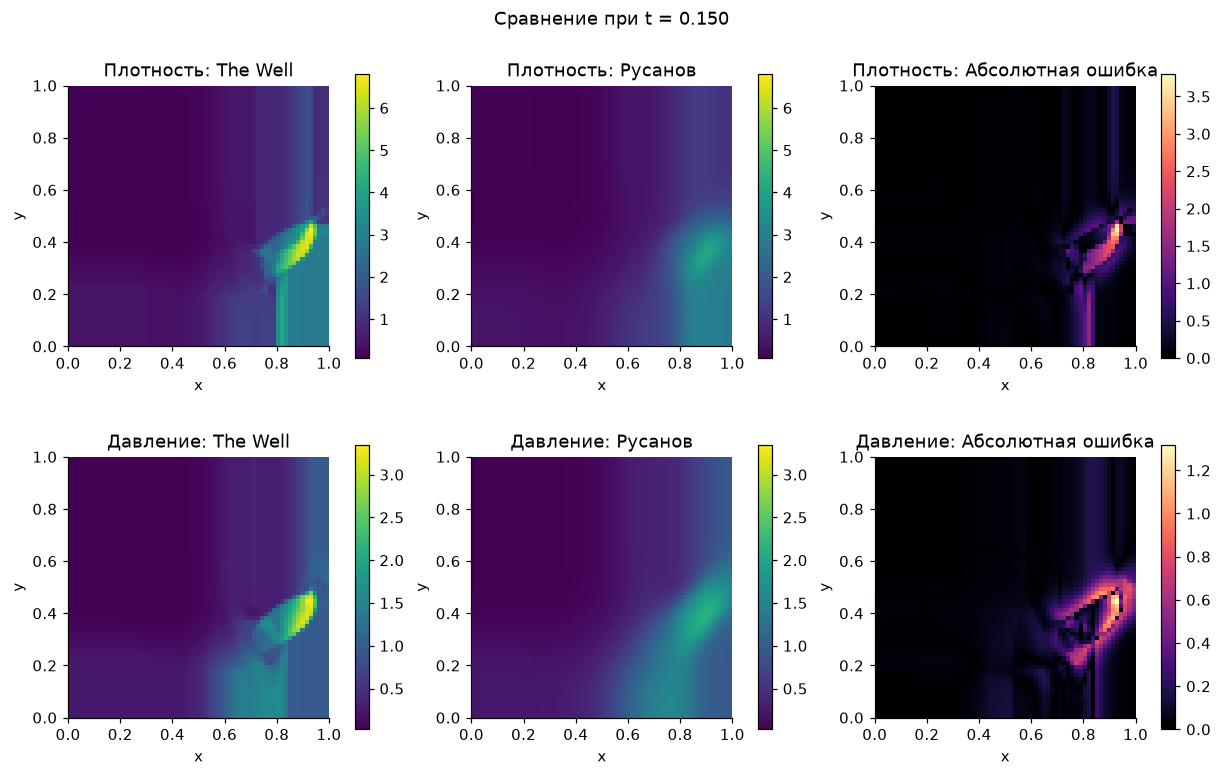

In [8]:
well_metrics = {}
rows = ["| Параметр | RMSE rho | rel.L2 rho | RMSE p | rel.L2 p |", "|---|---:|---:|---:|---:|"]
for label, values in predictions.items():
    rho_metrics = error_metrics(values[3:,...,0], reference_3d[3:,...,0])
    p_metrics = error_metrics(values[3:,...,4], reference_3d[3:,...,4])
    well_metrics[label] = {"density":rho_metrics, "pressure":p_metrics}
    rows.append(f"| {label} | {rho_metrics['rmse']:.5f} | {rho_metrics['relative_l2']:.2%} | {p_metrics['rmse']:.5f} | {p_metrics['relative_l2']:.2%} |")
display(Markdown("**Проверка на поздних кадрах t = 0.06, 0.09, 0.12, 0.15:**\n\n" + "\n".join(rows)))
fig = plot_comparison(solution[-1,:,:,0,:], reference[-1], times[-1])
fig.savefig(FIGURES / "well_comparison.png", dpi=150)
plt.show()

Цветовые шкалы данных и расчёта одинаковы внутри каждой строки. Справа показана
абсолютная ошибка. Для схемы первого порядка ожидаемо сглаживание узких структур:
восстановление правильного $\gamma$ не устраняет численную диффузию.

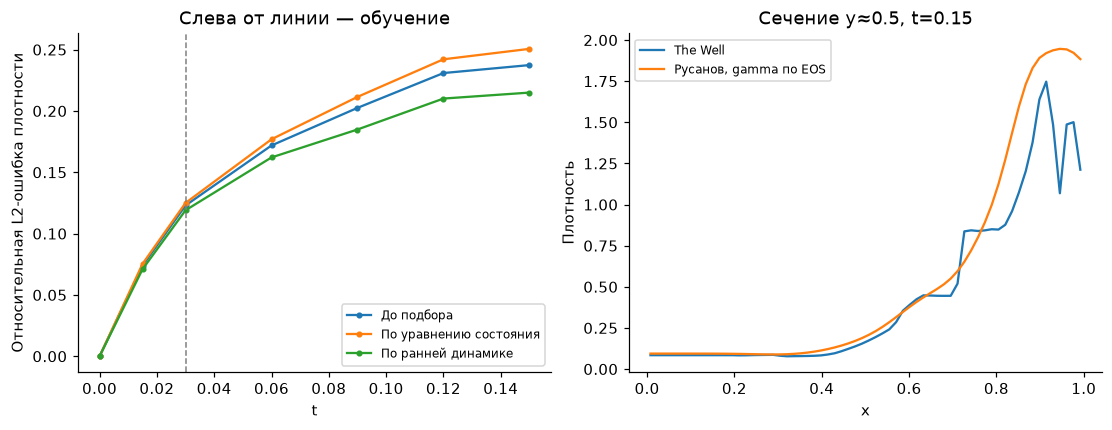

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
for label, values in predictions.items():
    errors = [error_metrics(a[...,0], b[...,0])["relative_l2"] for a,b in zip(values, reference_3d)]
    axes[0].plot(times, errors, "o-", markersize=3, label=label)
axes[0].axvline(times[2], color="gray", linestyle="--", linewidth=1)
axes[0].set(xlabel="t", ylabel="Относительная L2-ошибка плотности", title="Слева от линии — обучение")
axes[0].legend(fontsize=8)
x = (np.arange(n) + 0.5)/n
axes[1].plot(x, reference[-1,:,n//2,0], label="The Well")
axes[1].plot(x, solution[-1,:,n//2,0,0], label="Русанов, gamma по EOS")
axes[1].set(xlabel="x", ylabel="Плотность", title=f"Сечение y≈0.5, t={times[-1]:.2f}")
axes[1].legend(fontsize=8)
fig.savefig(FIGURES / "well_errors.png", dpi=150)
plt.show()

## 6. Независимые начальные данные: ANU / Fyris

Из HTML-таблиц ANU загружены состояния четырёх квадрантов. Ниже используются
случаи 3 и 6, $\gamma=1.4$, открытые границы и конечное время $t=0.3$.
В первом случае давление различается между квадрантами; во втором начальное
давление одинаково, но различаются скорости и плотности.

Сравним сетки $32^2$ и $64^2$ с усреднённым решением той же схемы на $128^2$.
Это проверка сеточной согласованности: расчёт $128^2$ **не является точным эталоном**.
Для плоской задачи достаточно одного слоя по z; код решателя остаётся тем же.

ANU 3, 32²: rel.L2 rho = 9.109%
ANU 3, 64²: rel.L2 rho = 4.298%


ANU 6, 32²: rel.L2 rho = 8.967%
ANU 6, 64²: rel.L2 rho = 4.029%


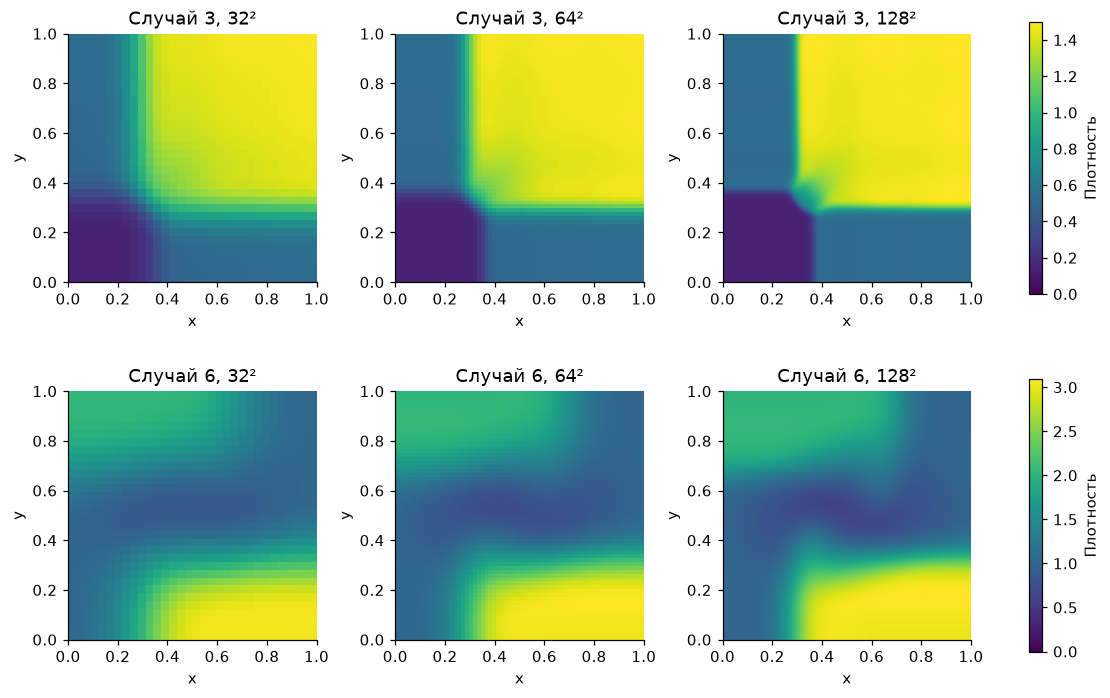

In [10]:
anu_results, anu_metrics = {}, {}
for case_id in (3,6):
    case = load_anu_case(case_id, DATA)
    quadrants = dict(zip(("UR","UL","LL","LR"), case["primitive"]))
    fields = {}
    for resolution in (32,64,128):
        state = quadrant_state(quadrants, resolution, 1)
        fields[resolution] = EulerSolver(gamma=case["gamma"]).solve(
            state, [0,case["final_time"]], (1/resolution,1/resolution,1))[-1,:,:,0,:]
    anu_results[case_id] = fields
    fine = primitive_to_conservative(fields[128], case["gamma"])
    anu_metrics[str(case_id)] = {}
    for resolution in (32,64):
        averaged = conservative_to_primitive(coarsen_conservative(fine,128//resolution), case["gamma"])
        metrics = error_metrics(fields[resolution][...,0], averaged[...,0])
        anu_metrics[str(case_id)][str(resolution)] = metrics
        print(f"ANU {case_id}, {resolution}²: rel.L2 rho = {metrics['relative_l2']:.3%}")
fig, axes = plt.subplots(2,3,figsize=(10,6.5),layout="constrained")
for row, case_id in enumerate((3,6)):
    vmax = max(field[...,0].max() for field in anu_results[case_id].values())
    for col, resolution in enumerate((32,64,128)):
        shown = axes[row,col].imshow(anu_results[case_id][resolution][...,0].T,
                origin="lower",extent=(0,1,0,1),vmin=0,vmax=vmax,cmap="viridis")
        axes[row,col].set(title=f"Случай {case_id}, {resolution}²",xlabel="x",ylabel="y")
    fig.colorbar(shown,ax=axes[row,:],shrink=0.8,label="Плотность")
fig.savefig(FIGURES / "anu_grids.png",dpi=150)
plt.show()

## 7. Проверка в 3D: перенос энтропийной волны

Чтобы проверить именно третье направление, используем точное гладкое решение:
$$\rho=1+0.2\sin(2\pi(x-0.3t))\sin(2\pi(y+0.2t))\sin(2\pi(z-0.1t)),$$
$$\mathbf v=(0.3,-0.2,0.1),\qquad p=1.$$
При постоянных давлении и скорости все уравнения сводятся к переносу плотности.
Границы периодические. Это аналитическая проверка, а не ещё один внешний датасет.

Солвер хранит средние по объёму. Поэтому начальное и точное конечное состояния
содержат множитель $\operatorname{sinc}(1/N)^3$ при произведении синусов.
Сравнение проводится при $t=0.1$ на сетках $16^3$ и $32^3$.

16³: RMSE rho=0.027953; max drift(U)=9.770e-15


32³: RMSE rho=0.015944; max drift(U)=1.044e-13
Наблюдаемый порядок по двум сеткам: 0.81


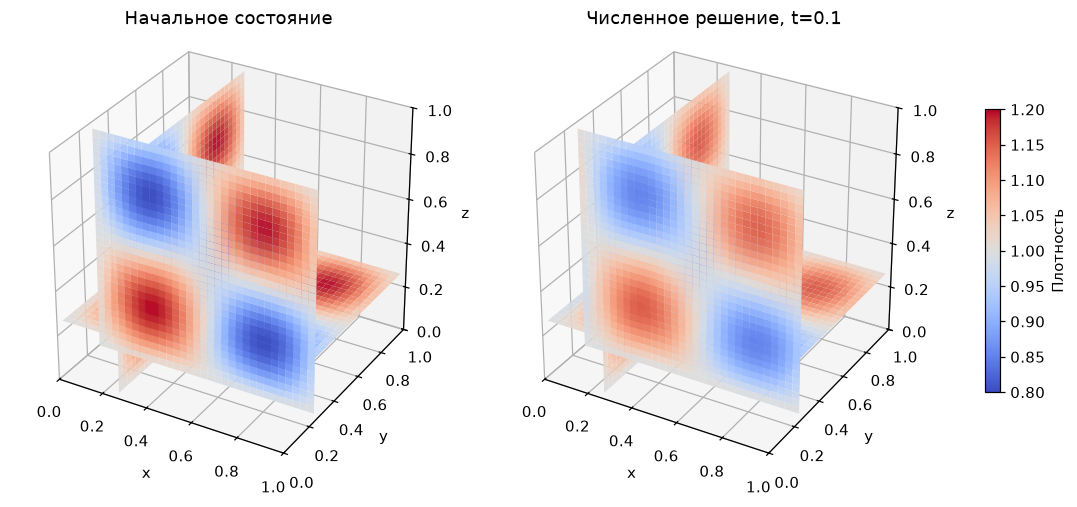

In [11]:
volume_metrics = {}
for resolution in (16,32):
    start = entropy_wave(resolution)
    trajectory = EulerSolver(boundary=("periodic",)*3).solve(
        start, [0,0.05,0.1], (1/resolution,)*3)
    exact = entropy_wave(resolution,time=0.1)
    metrics = error_metrics(trajectory[-1,...,0],exact[...,0])
    initial_totals = primitive_to_conservative(start).mean(axis=(0,1,2))
    final_totals = primitive_to_conservative(trajectory[-1]).mean(axis=(0,1,2))
    drift = float(np.max(abs(final_totals-initial_totals)))
    volume_metrics[str(resolution)] = {**metrics,"max_conservation_drift":drift}
    print(f"{resolution}³: RMSE rho={metrics['rmse']:.6f}; max drift(U)={drift:.3e}")
order = np.log2(volume_metrics["16"]["rmse"]/volume_metrics["32"]["rmse"])
print(f"Наблюдаемый порядок по двум сеткам: {order:.2f}")
fig = plot_volume(start,trajectory[-1],0.1)
fig.savefig(FIGURES / "volume_3d.png",dpi=150)
plt.show()

Сечения выше проходят по x, y и z. Цвет — плотность; это пространственный объём,
а не график высоты двумерного поля. Первый порядок схемы даёт заметное затухание
волны. Уменьшение ошибки с измельчением сетки и сохранение интегралов проверяют
разные свойства метода.

In [12]:
results = {
    "gamma_expected":gamma_expected, "eos_fit":asdict(eos_fit),
    "eos_test":eos_test_metrics, "trajectory_fit":asdict(trajectory_fit),
    "times":times.tolist(), "train_frames":[1,2], "test_frames":[4,6,8,10],
    "well_test_metrics":well_metrics, "anu_grid_metrics":anu_metrics,
    "volume_3d":volume_metrics, "observed_order_3d":float(order),
    "data_manifest_sha256":__import__("hashlib").sha256((DATA/"sources.json").read_bytes()).hexdigest(),
    "time_interpretation":"source_time * 0.015, from pinned dataset card",
    "grid_interpretation":"uniform finite volumes in [0,1], dx=1/N; source labels preserved",
}
(ROOT/"results"/"metrics.json").write_text(json.dumps(results,ensure_ascii=False,indent=2)+"\n",encoding="utf-8")
rho_error = well_metrics["По уравнению состояния"]["density"]["relative_l2"]
p_error = well_metrics["По уравнению состояния"]["pressure"]["relative_l2"]
display(Markdown(
    f"### Выводы\n\n"
    f"По уравнению состояния получено γ={eos_fit.gamma:.6f} при ожидаемом 1.4. "
    f"Подбор по ранним кадрам дал γ={trajectory_fit.gamma:.4f}. Это другая задача оптимизации: "
    f"результат зависит и от численной ошибки схемы.\n\n"
    f"На четырёх поздних кадрах The Well расчёт с γ из EOS имеет относительную L2-ошибку "
    f"{rho_error:.2%} по плотности и {p_error:.2%} по давлению. "
    f"Для трёхмерной гладкой волны наблюдаемый порядок равен {order:.2f}.\n\n"
    "Схема воспроизводит движение газа, но сглаживает разрывы. "
    "Для лучшего разрешения фронтов нужны более мелкая сетка либо реконструкция более высокого порядка. "
    "По одной короткой траектории нельзя делать вывод о качестве на всём The Well."
))

### Выводы

По уравнению состояния получено γ=1.400000 при ожидаемом 1.4. Подбор по ранним кадрам дал γ=1.1185. Это другая задача оптимизации: результат зависит и от численной ошибки схемы.

На четырёх поздних кадрах The Well расчёт с γ из EOS имеет относительную L2-ошибку 22.49% по плотности и 21.92% по давлению. Для трёхмерной гладкой волны наблюдаемый порядок равен 0.81.

Схема воспроизводит движение газа, но сглаживает разрывы. Для лучшего разрешения фронтов нужны более мелкая сетка либо реконструкция более высокого порядка. По одной короткой траектории нельзя делать вывод о качестве на всём The Well.

## Источники и воспроизводимость

- Lax P. D., Liu X.-D. *Solution of Two-Dimensional Riemann Problems of Gas Dynamics
  by Positive Schemes*. SIAM J. Sci. Comput. 19(2), 319–340, 1998.
  [DOI](https://doi.org/10.1137/S1064827595291819).
- Liska R., Wendroff B. *Comparison of Several Difference Schemes on 1D and 2D Test
  Problems for the Euler Equations*. SIAM J. Sci. Comput. 25(3), 995–1017, 2003.
  [DOI](https://doi.org/10.1137/S1064827502402120).
- Ohana R. et al. *The Well: a Large-Scale Collection of Diverse Physics Simulations
  for Machine Learning*. 2024. [Статья](https://arxiv.org/abs/2412.00568),
  [описание Euler](https://polymathic-ai.org/the_well/datasets/euler_multi_quadrants_openBC/),
  [данные](https://huggingface.co/datasets/polymathic-ai/euler_multi_quadrants_openBC).
  Использованный фрагмент: CC-BY-4.0; сделаны выборка кадров и усреднение.
- ANU / Fyris, Liska–Wendroff tests: [настройки](https://www.mso.anu.edu.au/fyris/lw2driemann.html),
  [случай 3](https://www.mso.anu.edu.au/fyris/lw2drtst03.html),
  [случай 6](https://www.mso.anu.edu.au/fyris/lw2drtst06.html).

Команды повторного запуска и тестирования — в `README.md`. Все классы и функции
вынесены в `src/euler_lab`; ноутбук задаёт эксперименты и показывает результаты.
Участие ИИ и использованные инструкции описаны в `AI_USAGE.md` и `docs/ai/`.